# Creando un Modelo de Difusión desde cero

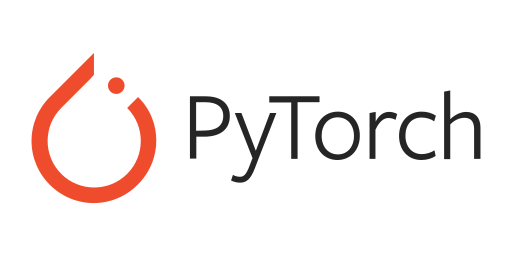

version 1.0.0

## 0. Instalación de las librerías necesarias:

In [1]:
!pip install torch
!pip install torchvision
!pip install matplotlib



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
!nvidia-smi

Sat Jun 13 22:49:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.47        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   53C    P0             28W /  140W |    1083MiB /   8192MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##1. Se definen funciones tipo utils y se importan las librerías:

In [3]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython.display import Image
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# Funciones para cargar el dataset FashionMNIST desde Pytorch:
def load_fashionMNIST(data_transform, train=True):
    return torchvision.datasets.FashionMNIST(
        "./data/",
        download=True,
        train=train,
        transform=data_transform,
    )


def load_transformed_fashionMNIST(img_size, batch_size):
    data_transforms = [
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),  # convierte la imagen a tensor y automaticamente escala los valores entre [0,1]
        transforms.RandomHorizontalFlip(),
        transforms.Lambda(lambda t: (t * 2) - 1)  # escala entre [-1, 1] para facilitar el entrenamiento
    ]

    data_transform = transforms.Compose(data_transforms)
    train_set = load_fashionMNIST(data_transform, train=True)
    test_set = load_fashionMNIST(data_transform, train=False)
    data = torch.utils.data.ConcatDataset([train_set, test_set])
    dataloader = DataLoader(data, batch_size=batch_size, shuffle=True, drop_last=True)
    return data, dataloader

# Funcion para visualizar
def show_tensor_image(image):
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2), # esto revierte el escalado inicial
        transforms.Lambda(lambda t: torch.minimum(torch.tensor([1]), t)), # asegura que el maximo valor no super 1
        transforms.Lambda(lambda t: torch.maximum(torch.tensor([0]), t)), # asegura que el minimo valor no es menor que 0
        transforms.ToPILImage(),
    ])
    plt.imshow(reverse_transforms(image[0].detach().cpu()))

# Funcion para convertir un tensor en una imagen
def to_image(tensor, to_pil=True):
    tensor = (tensor + 1) / 2
    ones = torch.ones_like(tensor)
    tensor = torch.min(torch.stack([tensor, ones]), 0)[0]
    zeros = torch.zeros_like(tensor)
    tensor = torch.max(torch.stack([tensor, zeros]), 0)[0]
    if not to_pil:
        return tensor
    return transforms.functional.to_pil_image(tensor)

# Funcion para visualizar imagenes generadas
def plot_generated_images(noise, result):
    plt.figure(figsize=(8,8))
    nrows = 1
    ncols = 2
    samples = {
        "Ruido aleatorio" : noise,
        "Imagen generada" : result
    }
    for i, (title, img) in enumerate(samples.items()):
        ax = plt.subplot(nrows, ncols, i+1)
        ax.set_title(title)
        show_tensor_image(img)
    plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.optim import Adam

# Librerias de visualizacion
import matplotlib.pyplot as plt
from IPython.display import Image

IMG_SIZE = 16
IMG_CH = 1 # un canal porque son imagenes en blanco y negro
BATCH_SIZE = 128
data, dataloader = load_transformed_fashionMNIST(IMG_SIZE, BATCH_SIZE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
import torch
torch.set_float32_matmul_precision('high')


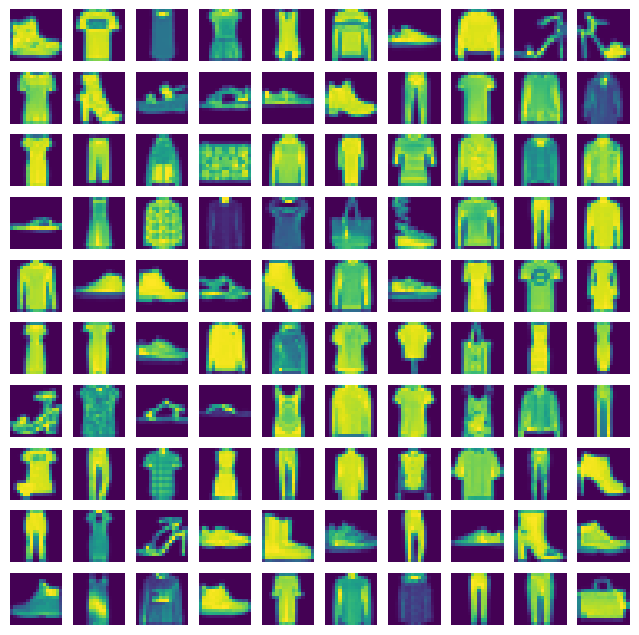

In [6]:
# Vamos a ver algunas imagenes del dataset:
plt.figure(figsize=(8,8))
nrows = 10
ncols = 10

for i in range(nrows*ncols):
    ax = plt.subplot(nrows, ncols, i+1)
    ax.axis('off')
    show_tensor_image(data[i])
plt.show()

## 2. Proceso de Difusión hacia delante

Como sabemos, `T` define el número de pasos que utilizaremos para añadir ruido aleatorio a las imágenes. Por ello utilizaremos la variable `t` para guardar el valor de cada `timestep`.

La variable `B` es el scheduler de nuestro proceso de difusión. Controla de manera lineal cuánto ruido vamos a añadir a nuestras imágenes en cada timestep `t`.

In [7]:
nrows = 10
ncols = 15

T = nrows * ncols
start = 0.0001
end = 0.02

# Scheduler Lineal:
B = torch.linspace(start, end, T).to(device)
print(B)

tensor([1.0000e-04, 2.3356e-04, 3.6711e-04, 5.0067e-04, 6.3423e-04, 7.6779e-04,
        9.0134e-04, 1.0349e-03, 1.1685e-03, 1.3020e-03, 1.4356e-03, 1.5691e-03,
        1.7027e-03, 1.8362e-03, 1.9698e-03, 2.1034e-03, 2.2369e-03, 2.3705e-03,
        2.5040e-03, 2.6376e-03, 2.7711e-03, 2.9047e-03, 3.0383e-03, 3.1718e-03,
        3.3054e-03, 3.4389e-03, 3.5725e-03, 3.7060e-03, 3.8396e-03, 3.9732e-03,
        4.1067e-03, 4.2403e-03, 4.3738e-03, 4.5074e-03, 4.6409e-03, 4.7745e-03,
        4.9081e-03, 5.0416e-03, 5.1752e-03, 5.3087e-03, 5.4423e-03, 5.5758e-03,
        5.7094e-03, 5.8430e-03, 5.9765e-03, 6.1101e-03, 6.2436e-03, 6.3772e-03,
        6.5107e-03, 6.6443e-03, 6.7779e-03, 6.9114e-03, 7.0450e-03, 7.1785e-03,
        7.3121e-03, 7.4456e-03, 7.5792e-03, 7.7128e-03, 7.8463e-03, 7.9799e-03,
        8.1134e-03, 8.2470e-03, 8.3805e-03, 8.5141e-03, 8.6477e-03, 8.7812e-03,
        8.9148e-03, 9.0483e-03, 9.1819e-03, 9.3154e-03, 9.4490e-03, 9.5826e-03,
        9.7161e-03, 9.8497e-03, 9.9832e-

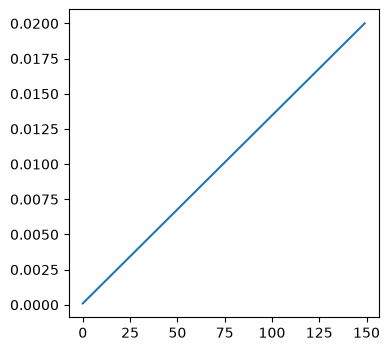

In [8]:
# Graficamos el scheduler lineal:
plt.figure(figsize=(4,4))
plt.plot(B.cpu())
plt.show()

In [9]:
# Cosine Scheduler:
import torch
import math

def cosine_beta_schedule_scaled(T, min_beta=0.0001, max_beta=0.02, s=0.008):
    steps = T + 1
    x = torch.linspace(0, T, steps)

    # Producto cumulativo de alphas:
    alpha_cumprod = torch.cos(((x / T) + s) / (1 + s) * math.pi / 2) ** 2
    alpha_cumprod = alpha_cumprod / alpha_cumprod[0]  # Normalizar para hacer que alpha_bar[0] = 1

    # Convertir alpha_bar en betas:
    betas = 1 - (alpha_cumprod[1:] / alpha_cumprod[:-1])

    # Normalizar los betas entre [0, 1]
    betas = (betas - betas.min()) / (betas.max() - betas.min())

    # Escalar los betas al rango deseado:
    betas = betas * (max_beta - min_beta) + min_beta

    return betas

B_cos = cosine_beta_schedule_scaled(T).to(device)

print(B_cos)

tensor([1.0000e-04, 1.0430e-04, 1.0860e-04, 1.1290e-04, 1.1720e-04, 1.2151e-04,
        1.2582e-04, 1.3015e-04, 1.3448e-04, 1.3881e-04, 1.4316e-04, 1.4751e-04,
        1.5188e-04, 1.5626e-04, 1.6065e-04, 1.6506e-04, 1.6947e-04, 1.7391e-04,
        1.7837e-04, 1.8284e-04, 1.8733e-04, 1.9184e-04, 1.9638e-04, 2.0093e-04,
        2.0551e-04, 2.1012e-04, 2.1475e-04, 2.1941e-04, 2.2409e-04, 2.2881e-04,
        2.3356e-04, 2.3835e-04, 2.4316e-04, 2.4801e-04, 2.5290e-04, 2.5783e-04,
        2.6279e-04, 2.6780e-04, 2.7285e-04, 2.7795e-04, 2.8309e-04, 2.8829e-04,
        2.9352e-04, 2.9882e-04, 3.0417e-04, 3.0956e-04, 3.1503e-04, 3.2055e-04,
        3.2613e-04, 3.3178e-04, 3.3750e-04, 3.4328e-04, 3.4914e-04, 3.5507e-04,
        3.6108e-04, 3.6717e-04, 3.7334e-04, 3.7960e-04, 3.8595e-04, 3.9238e-04,
        3.9892e-04, 4.0556e-04, 4.1230e-04, 4.1915e-04, 4.2611e-04, 4.3318e-04,
        4.4038e-04, 4.4770e-04, 4.5515e-04, 4.6274e-04, 4.7047e-04, 4.7835e-04,
        4.8637e-04, 4.9456e-04, 5.0290e-

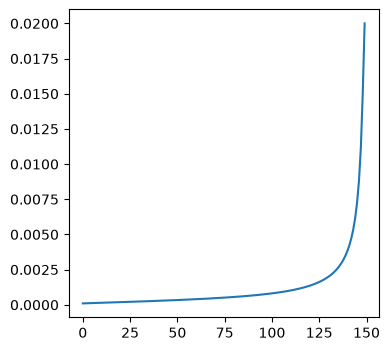

In [10]:
# Graficamos el Cosine Scheduler:
plt.figure(figsize=(4,4))
plt.plot(B_cos.cpu())
plt.show()

Como sabemos, existe una regla (la regla amarilla de las diapositivas de teoría), con la que podemos ir a cualquier estado x_t desde x_0. Así:

$q(\mathbf{x}_{t}|\mathbf{x}_{0})=\mathcal{N}(\mathbf{x}_{t};\sqrt{\bar{\alpha}_{t}} \cdot x_{0},(1 - \bar{\alpha}_t) \cdot \mathbf{I})$

Que si lo traducimos a código sería:

`x_t = sqrt_a_bar_t * x_0 + sqrt_one_minus_a_bar_t * noise`

In [11]:
a = 1. - B
a_bar = torch.cumprod(a, dim=0)
sqrt_a_bar = torch.sqrt(a_bar)  # Coeficiente de la media
sqrt_one_minus_a_bar = torch.sqrt(1 - a_bar) # Coeficiente de la desv. típica

In [12]:
# Construimos nuestra funcion para calcular x_t y el ruido en función de x_0 y t:
def q(x_0, t):
    """
    Samples a new image from q
    Returns the noise applied to an image at timestep t

    x_0: the original image
    t: timestep
    """
    t = t.int()
    noise = torch.randn_like(x_0)  # genera un tensor con numeros aleatorios de una dist.normal con la misma forma que x_0
    sqrt_a_bar_t = sqrt_a_bar[t, None, None, None] # al indexar con None hacemos broadcasting
    sqrt_one_minus_a_bar_t = sqrt_one_minus_a_bar[t, None, None, None]

    x_t = sqrt_a_bar_t * x_0 + sqrt_one_minus_a_bar_t * noise

    return x_t, noise

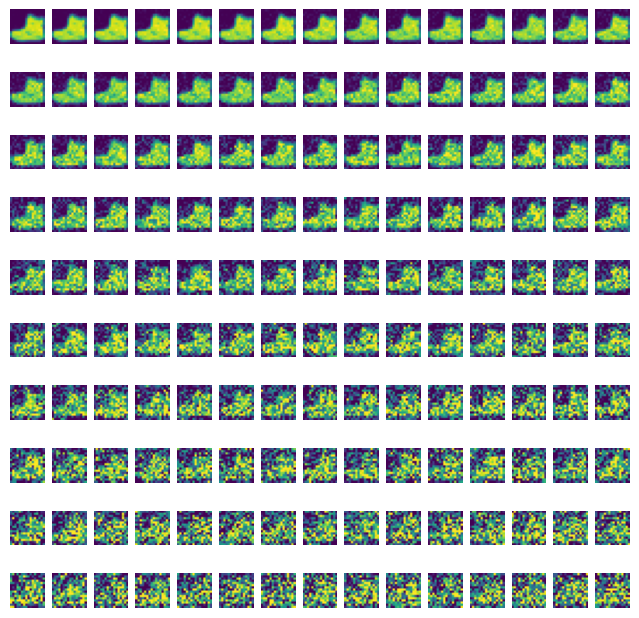

In [13]:
plt.figure(figsize=(8, 8))
x_0 = data[0][0].to(device)  # cogemos la primera imagen del dataset
x_t = x_0
xs = []  # guardamos x_t para cada timestep de T

for t in range(T):
    t_tenser = torch.Tensor([t]).type(torch.int64)
    x_t, _ = q(x_0, t_tenser)
    img = torch.squeeze(x_t).cpu()
    xs.append(img)
    ax = plt.subplot(nrows, ncols, t + 1)
    ax.axis('off')
    show_tensor_image(x_t)

## 3. Definir la arquitectura de la U-Net

Para poder empezar a predecir el ruido necesitamos construir la arquitectura de nuestra red neuronal U-Net. Para ello, vamos a definir varias clases.

La primera, es un bloque de embedding de tiempo, que utilizaremos para indicar a nuestra red en qué timestemp se encuentra cada imagen de input.

In [14]:
class EmbedBlock(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.input_dim = input_dim
        layers = [
            nn.Linear(input_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1))
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, input):
        input = input.view(-1, self.input_dim)
        return self.model(input)

Después haremos el bloque de downsample que se encargará de reducir el tamaño de la imagen y comprimirla

In [15]:
class DownBlock(nn.Module):
    def __init__(self, in_chs, out_chs):
        kernel_size = 3
        stride = 1
        padding = 1

        super().__init__()
        layers = [
            nn.Conv2d(in_chs, out_chs, kernel_size, stride, padding),  # capas de Convolucion para reducir el tamaño de las imagenes
            nn.BatchNorm2d(out_chs),
            nn.ReLU(),
            nn.Conv2d(out_chs, out_chs, kernel_size, stride, padding),
            nn.BatchNorm2d(out_chs),
            nn.ReLU(),
            nn.MaxPool2d(2)
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

Y por último definimos el bloque de upsample, que hace lo contrario, aumentar el tamaño de la imagen hasta el tamaño original

In [16]:
class UpBlock(nn.Module):
    def __init__(self, in_chs, out_chs):
        # Convolution variables
        kernel_size = 3
        stride = 1
        padding = 1

        # Transpose variables
        strideT = 2
        out_paddingT = 1

        super().__init__()
        layers = [
            nn.ConvTranspose2d(2 * in_chs, out_chs, kernel_size, strideT, padding, out_paddingT),  # usamos Convolucion Traspuesta para ampliar el tamaño de las imagenes
            nn.BatchNorm2d(out_chs),
            nn.ReLU(),
            nn.Conv2d(out_chs, out_chs, kernel_size, stride, padding),
            nn.BatchNorm2d(out_chs),
            nn.ReLU()
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        x = self.model(x)
        return x

Por último, ponemos todos los bloques juntos para crear la U-Net:

In [17]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        img_chs = IMG_CH
        down_chs = (16, 32, 64)  # numero de canales en cada paso de downsampling
        up_chs = down_chs[::-1]  # reverse de los down_chs
        latent_image_size = IMG_SIZE // 4  # tamaño de la imagen en el bottleneck: 2 ** (len(down_chs) - 1)
        t_dim = 1  # el timestep es un valor escalar

        # Primeras capas de convolucion:
        self.down0 = nn.Sequential(
            nn.Conv2d(img_chs, down_chs[0], 3, padding=1),
            nn.BatchNorm2d(down_chs[0]),
            nn.ReLU()
        )

        # Downsample
        self.down1 = DownBlock(down_chs[0], down_chs[1])
        self.down2 = DownBlock(down_chs[1], down_chs[2])
        self.to_vec = nn.Sequential(nn.Flatten(), nn.ReLU())

        # Embeddings
        self.dense_emb = nn.Sequential(
            nn.Linear(down_chs[2]*latent_image_size**2, down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[2]*latent_image_size**2),
            nn.ReLU()
        )
        self.temb_1 = EmbedBlock(t_dim, up_chs[0])
        self.temb_2 = EmbedBlock(t_dim, up_chs[1])

        # Upsample
        self.up0 = nn.Sequential(
            nn.Unflatten(1, (up_chs[0], latent_image_size, latent_image_size)),
            nn.Conv2d(up_chs[0], up_chs[0], 3, padding=1),
            nn.BatchNorm2d(up_chs[0]),
            nn.ReLU(),
        )
        self.up1 = UpBlock(up_chs[0], up_chs[1])
        self.up2 = UpBlock(up_chs[1], up_chs[2])

        # Match output channels
        self.out = nn.Sequential(
            nn.Conv2d(up_chs[-1], up_chs[-1], 3, 1, 1),
            nn.BatchNorm2d(up_chs[-1]),
            nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_chs, 3, 1, 1)
        )

    def forward(self, x, t):
        down0 = self.down0(x)
        down1 = self.down1(down0)
        down2 = self.down2(down1)
        latent_vec = self.to_vec(down2) # to_vect() hace un Flatten

        t = t.float() / T  # noramlizacion para que los valores de t esten entre [0, 1] y no [0, T]
        latent_vec = self.dense_emb(latent_vec)
        temb_1 = self.temb_1(t)  # se definen 2 time embeddings porque cada uno se inyecta al proceso de upsampling en un punto distinto
        temb_2 = self.temb_2(t)

        up0 = self.up0(latent_vec)
        up1 = self.up1(up0+temb_1, down2)
        up2 = self.up2(up1+temb_2, down1)
        return self.out(up2)

In [18]:
model = UNet()
print("Num parametros: ", sum(p.numel() for p in model.parameters()))
model = torch.compile(UNet().to(device))

Num parametros:  240385


## 4. Definir la función de coste
En este caso utilizamos el Mean Squared Error (MSE)

In [19]:
def get_loss(real_noise, pred_noise):
    loss = F.mse_loss(real_noise, pred_noise)
    return loss

## 5. Entrenamiento del modelo

In [20]:
optimizer = Adam(model.parameters(), lr=0.001)
epochs = 3
ncols = 15  # tiene que ser divisor de T

model.train()
for epoch in range(epochs):  # para cada epoch
    for step, batch in enumerate(dataloader):  # para cada imagen del dataset
        optimizer.zero_grad()

        t = torch.randint(0, T, (BATCH_SIZE,), device=device)  # genero un timestamp aleatorio entre 0 y T
        x = batch[0].to(device)  # cogemos la imagen

        # Para esa imagen, se le añade ruido hasta el timestamp "t":
        x_noisy, noise = q(x, t)  # obtenemos la imagen con ruido y el ruido

        # Predecimos el ruido con el modelo:
        noise_pred = model(x_noisy, t)  # importante recordar que el timestamp "t" tiene que ser un input para el modelo

        # Calculamos el loss: cuanto se ha confundido prediciendo el ruido para esa imagen
        loss = get_loss(noise, noise_pred)

        # Por ultimo se hace la propagacion hacia atras:
        loss.backward()
        optimizer.step()

        if epoch % 1 == 0 and step % 100 == 0:
            print(f"Epoch {epoch} | Step {step:03d} | Loss: {loss.item()} ")

Epoch 0 | Step 000 | Loss: 1.1144466400146484 
Epoch 0 | Step 100 | Loss: 0.4228670597076416 
Epoch 0 | Step 200 | Loss: 0.3143088221549988 
Epoch 0 | Step 300 | Loss: 0.2455875426530838 
Epoch 0 | Step 400 | Loss: 0.25177210569381714 
Epoch 0 | Step 500 | Loss: 0.21739661693572998 
Epoch 1 | Step 000 | Loss: 0.2337435781955719 
Epoch 1 | Step 100 | Loss: 0.1967921406030655 
Epoch 1 | Step 200 | Loss: 0.1839127391576767 
Epoch 1 | Step 300 | Loss: 0.21291294693946838 
Epoch 1 | Step 400 | Loss: 0.19026176631450653 
Epoch 1 | Step 500 | Loss: 0.19826610386371613 
Epoch 2 | Step 000 | Loss: 0.20950651168823242 
Epoch 2 | Step 100 | Loss: 0.17464621365070343 
Epoch 2 | Step 200 | Loss: 0.18117329478263855 
Epoch 2 | Step 300 | Loss: 0.17918573319911957 
Epoch 2 | Step 400 | Loss: 0.16759949922561646 
Epoch 2 | Step 500 | Loss: 0.16221070289611816 


## 6. Inferencia: proceso de Difusión hacia atrás

Para realizar el proceso de difusión hacia detrás, se define una función que puede generar $\mathbf{x}_{t-1}$ a partir de $\mathbf{x}_t$.

$q(\mathbf{x}_{t-1}|\mathbf{x}_{t},\mathbf{x}_{0}) = \mathcal{N}(\mathbf{x}_{t-1};{\mathbf{\tilde{\mu}}}(\mathbf{x_t},\mathbf{x_0}), \tilde{\beta}_t \cdot \mathbf{I})$


<br>Como vimos en la teoría, despejando se puede obtener una estimación de la imagen original a partir de la imagen $\mathbf{x}_{t}$ y el ruido predicho $\mathbf{\epsilon}_t$:

${\mathbf{\tilde{\mu}}}_t = \frac{1}{\sqrt{\alpha_t}}(\mathbf{x_t}-\frac{1-\alpha_t}{\sqrt{1-\overline{\alpha_t}}}\mathbf{\epsilon}_t)$

<br>Finalmente, la imagen $\mathbf{x}_{t-1}$ se estima añadiendo un término de ruido ${\mathbf{\tilde{\mu}}}_t + \tilde{\beta}_t \cdot \mathbf{I}$. Haciendo esto para cada `t` hasta llegar a `t == 0` conseguimos la imagen original

In [21]:
# Se calcula 1 / raiz de alfa
sqrt_a_inv = torch.sqrt(1 / a)

# Se calcula el coeficiente del ruido predicho
pred_noise_coeff = (1 - a) / torch.sqrt(1 - a_bar)

In [22]:
@torch.no_grad()
def reverse_q(x_t, t, e_t):  # para quitar ruido necesitamos: una imagen con ruido (x_t), el timestamp en el que estamos (t), y el ruido predicho por el modelo en ese timestamp (e_t)
    t = torch.squeeze(t[0].int())
    pred_noise_coeff_t = pred_noise_coeff[t]
    sqrt_a_inv_t = sqrt_a_inv[t]

    # Se calcula una estimacion de x_0 (aqui lo llamamos u_t)
    u_t = sqrt_a_inv_t * (x_t - pred_noise_coeff_t * e_t)

    if t == 0:
        return u_t  # proceso de difusion hacia atras terminado!
    else:
        B_t = B[t-1]
        new_noise = torch.randn_like(x_t)
        return u_t + torch.sqrt(B_t) * new_noise

In [23]:
@torch.no_grad()
def sample_images(ncols, figsize=(8,8)):
    plt.figure(figsize=figsize)
    plt.axis("off")
    hidden_rows = T / ncols

    # Definimos un ruido aleatorio a partir del cual generar imágenes
    x_t = torch.randn((1, IMG_CH, IMG_SIZE, IMG_SIZE), device=device)

    # Vamos desde t=T quitando y añadiendo ruido hasta t=0:
    plot_number = 1
    for i in range(0, T)[::-1]:
        t = torch.full((1,), i, device=device)

        e_t = model(x_t, t)  # ruido predicho
        x_t = reverse_q(x_t, t, e_t)  # se calcula x(t-1) como funcion de la imagen actual (x_t), el timestep (t), y el ruido predicho (e_t)

        if i % hidden_rows == 0:
            ax = plt.subplot(1, ncols+1, plot_number)
            ax.axis('off')
            show_tensor_image(x_t.detach().cpu())
            plot_number += 1
    plt.show()

## 7. Generar imágenes a partir de ruido aleatorio con el modelo ya entrenado:

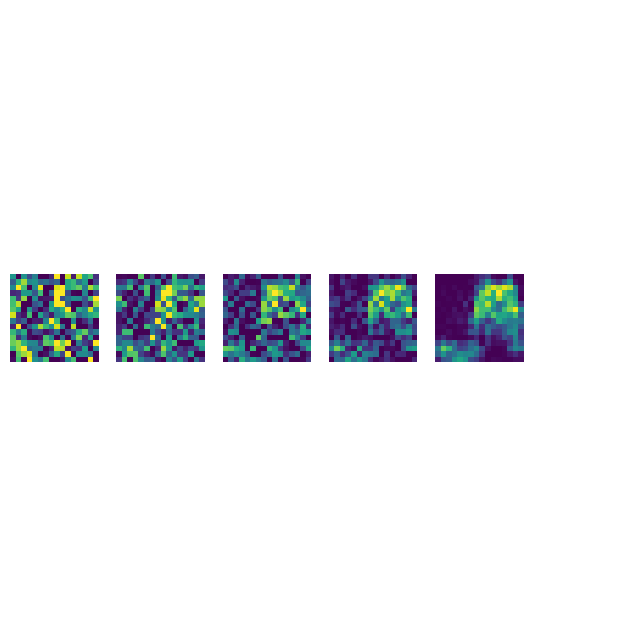

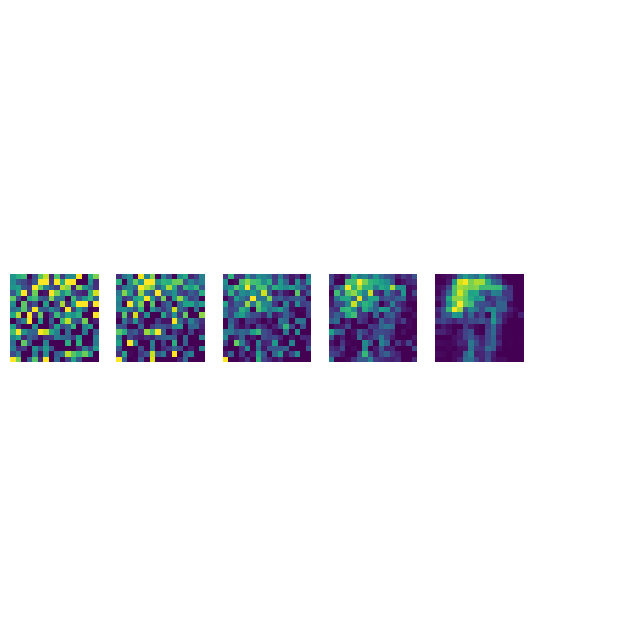

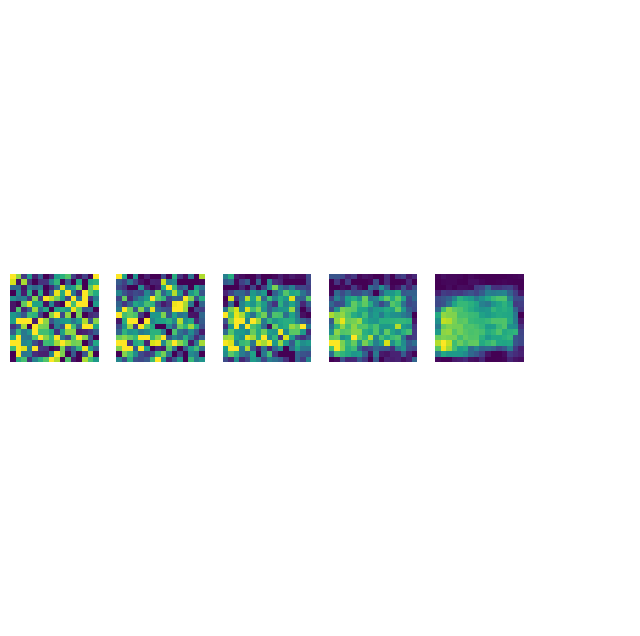

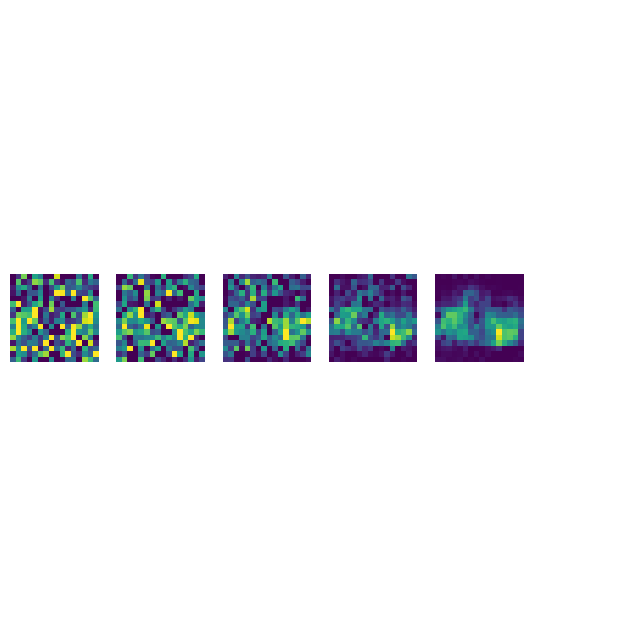

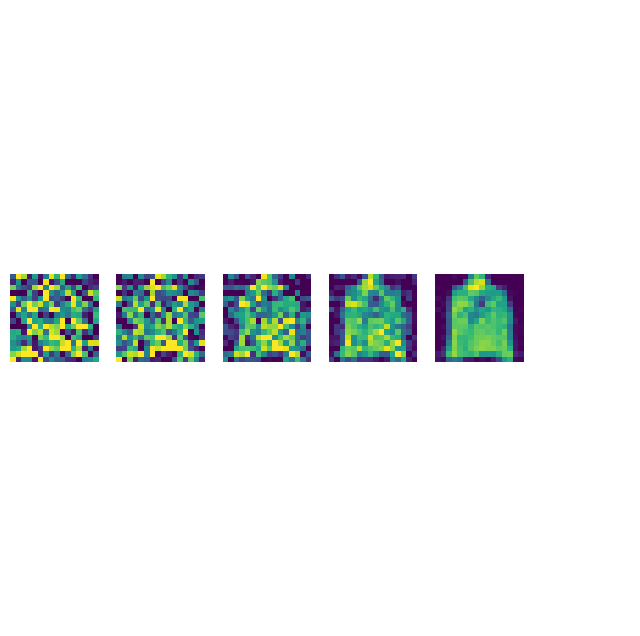

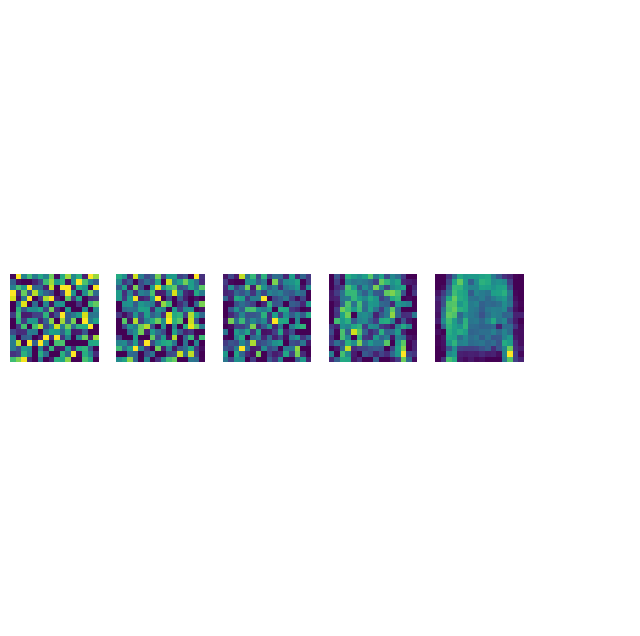

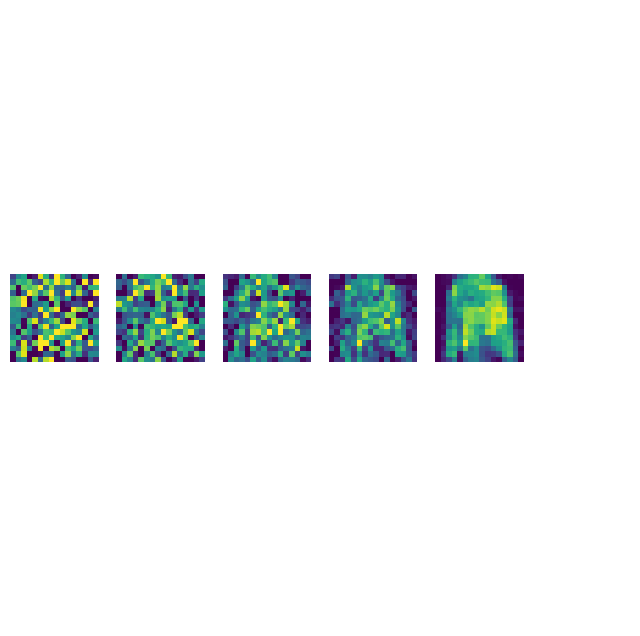

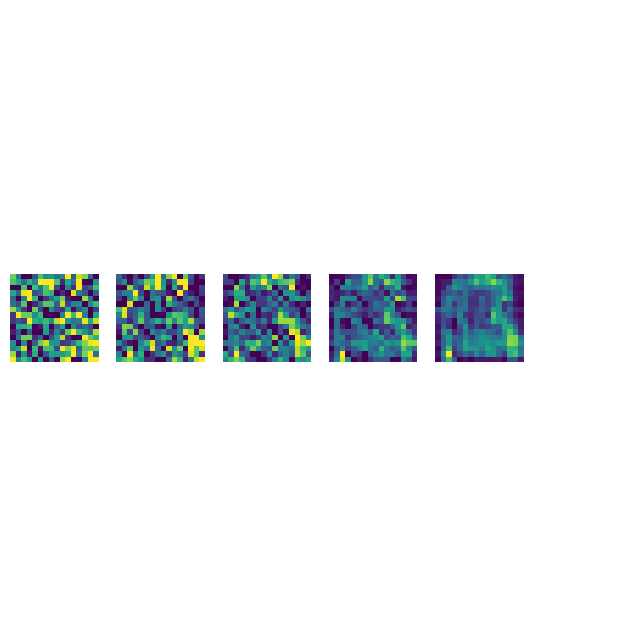

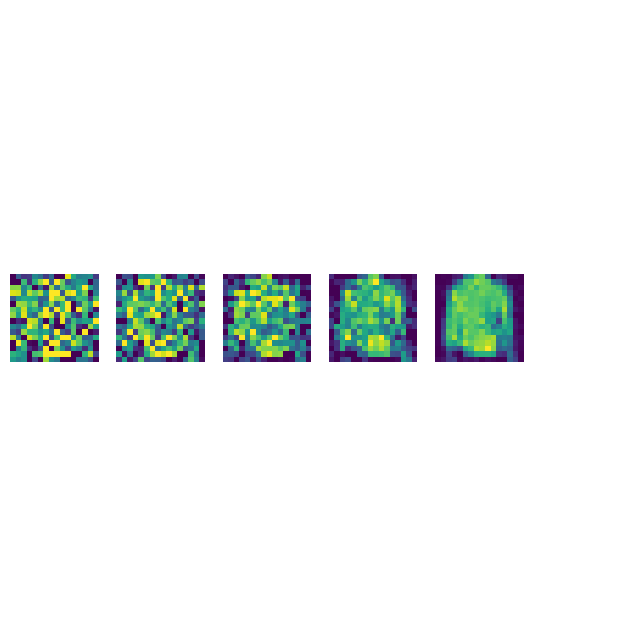

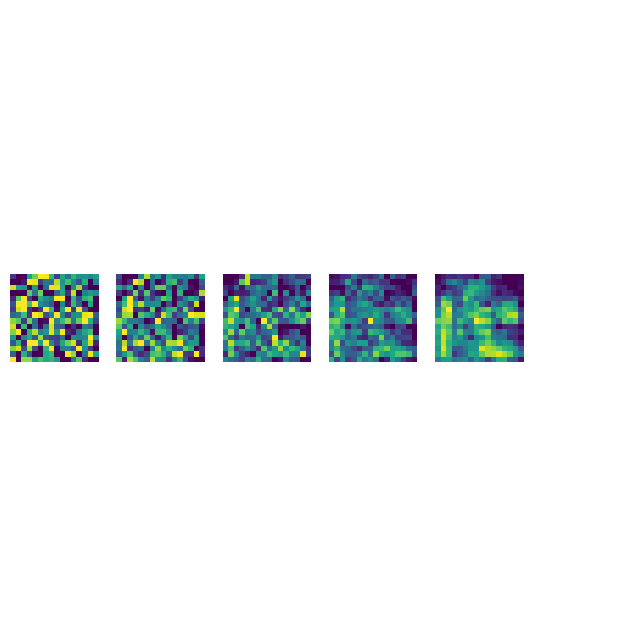

In [24]:
model.eval()
figsize=(8,8)
ncols = 5  # divisor de T
for _ in range(10):
    sample_images(ncols, figsize=figsize)